# California housing: exploring the data

Most of the regression notebooks after this one use the California housing dataset, so this is a look
at what's in it before modelling. The steps are the generic ones I'd go through for any new dataset:
description, shapes, types, distributions, summary stats, relationships.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

sns.set_theme(style="whitegrid")

## Loading

`as_frame=True` gives DataFrames, and `.frame` has the features and target together in one table.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
type(housing), list(housing.keys())

(sklearn.utils._bunch.Bunch,
 ['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

## 1. Description

In [3]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

Key points from the description:

* 20,640 rows, one per **census block group** (a small neighbourhood of roughly 600-3,000 people),
  from the 1990 US census
* 8 numeric features, no missing values
* target `MedHouseVal` is the median house value of the block group, in units of $100,000
* `AveRooms`, `AveBedrms` and `AveOccup` are per household, so blocks with few households and many empty
  houses (holiday areas) can have very large values

## 2. Shapes and types

In [4]:
housing.data.shape, housing.target.shape

((20640, 8), (20640,))

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


All float64, nothing missing. So no imputation or encoding needed, but scaling will matter for some models.

| feature | meaning |
|---|---|
| MedInc | median income in the block (tens of thousands of $) |
| HouseAge | median house age |
| AveRooms | average rooms per household |
| AveBedrms | average bedrooms per household |
| Population | block population |
| AveOccup | average people per household |
| Latitude, Longitude | location of the block |

In [6]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Distributions

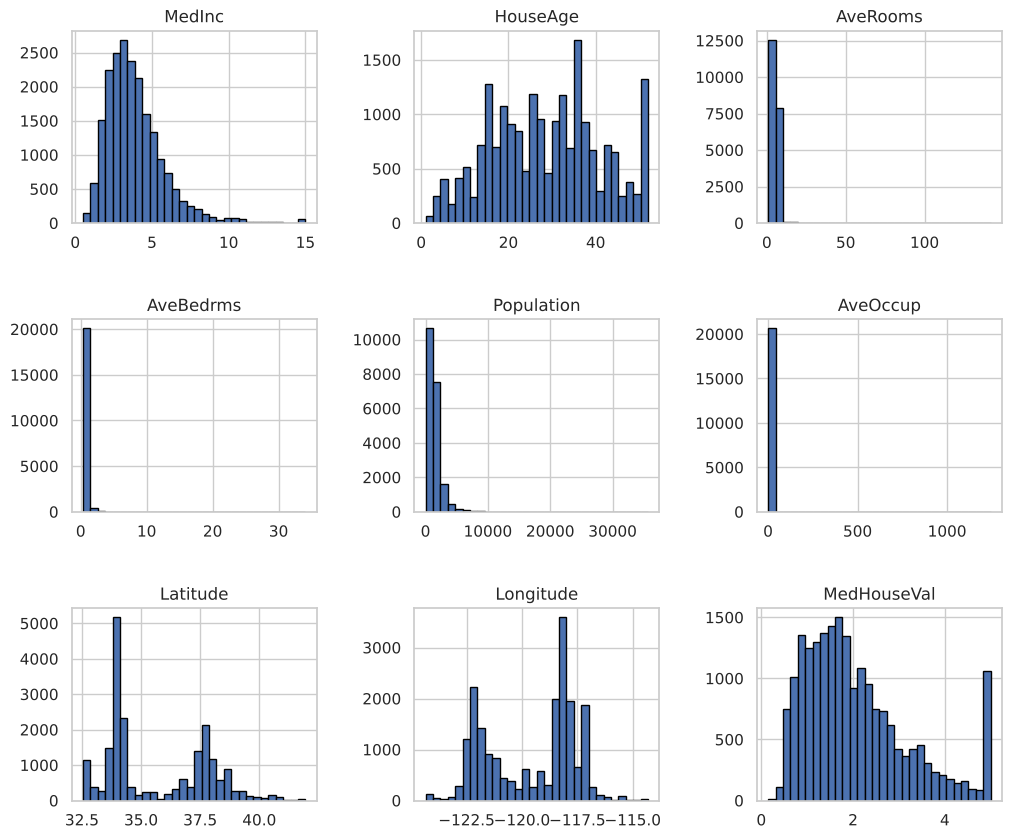

In [7]:
df.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

What stands out:

* **MedInc** is right-skewed: most blocks are in the 2-5 range with a long tail of high-income ones.
* **HouseAge** is spread fairly evenly, with a spike at 52. That looks like a cap: anything older was recorded as 52.
* **AveRooms, AveBedrms, Population, AveOccup** have most values bunched on the left and an almost
  invisible tail stretching far to the right, so there are some extreme values.
* **Latitude / Longitude** have two peaks each, which are the LA and San Francisco Bay areas.
* **MedHouseVal** has a big spike at the very end. Values above $500k were capped at 5.0.

The capping on the target is important: a model can't learn what a $700k block looks like because the data
just says "5.0".

In [8]:
(df['MedHouseVal'] >= 5.0).sum(), (df['HouseAge'] == 52).sum()

(np.int64(992), np.int64(1273))

## 4. Summary statistics

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


Compare the 75% column with max: AveRooms goes from about 6 to 141, AveOccup from about 3.3 to 1,243
(over a thousand people per household, which must be a group living situation or a data issue), and
Population from about 1,700 to 35,682. These are the outliers the histograms hinted at.

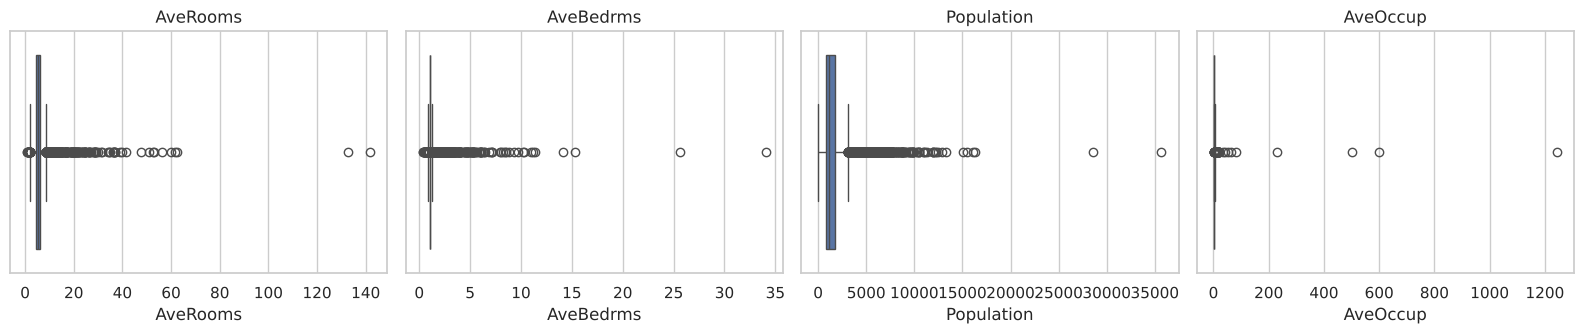

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 5. Location

Plotting longitude against latitude gives a map of California. Colour by house value and size by
population:

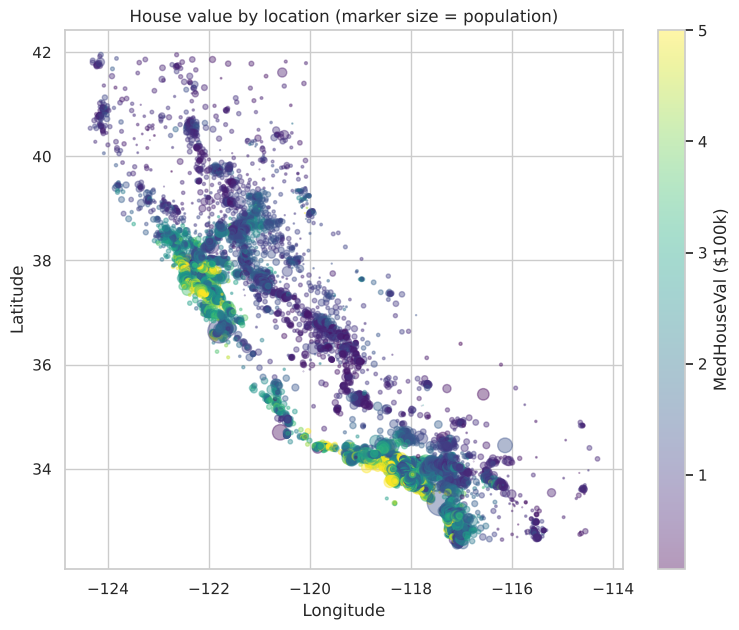

In [11]:
plt.figure(figsize=(9, 7))
plt.scatter(df['Longitude'], df['Latitude'], c=df['MedHouseVal'], cmap='viridis',
            s=df['Population'] / 100, alpha=0.4)
plt.colorbar(label='MedHouseVal ($100k)')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('House value by location (marker size = population)')
plt.show()

Expensive blocks are along the coast, especially around the Bay Area and LA. Inland it's much cheaper.
So location matters a lot, but not in a straight-line way: neither latitude nor longitude on its own
increases or decreases value steadily. A linear model will struggle to use them well, while trees and
KNN can pick up "this region is expensive" directly.

## 6. Relationship with the target

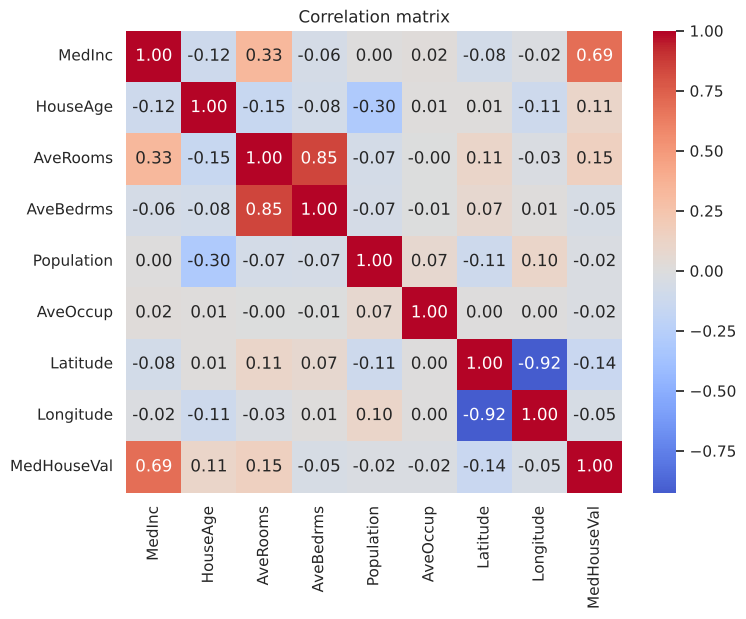

In [12]:
corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

In [13]:
corr['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False).round(3)

MedInc        0.688
AveRooms      0.152
HouseAge      0.106
AveOccup     -0.024
Population   -0.025
Longitude    -0.046
AveBedrms    -0.047
Latitude     -0.144
Name: MedHouseVal, dtype: float64

* **MedInc** is by far the strongest single predictor (r = 0.69).
* Everything else has a weak *linear* correlation with the target. That doesn't mean they're useless,
  latitude/longitude clearly matter from the map, just not linearly.
* AveRooms and AveBedrms are strongly correlated with each other (0.85), and Latitude and Longitude
  are strongly negatively correlated (-0.92, because the state runs diagonally).

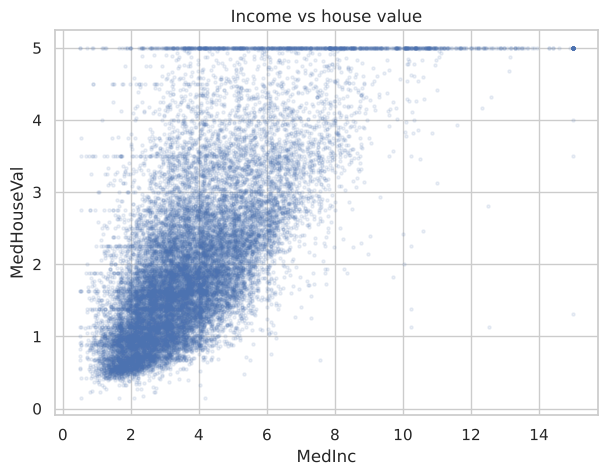

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.1, s=5)
plt.xlabel('MedInc'); plt.ylabel('MedHouseVal')
plt.title('Income vs house value')
plt.show()

Clear upward trend, but with a lot of spread, and the cap at 5.0 shows up as a horizontal line along the
top. There are fainter horizontal lines lower down as well: values like 1.375, 1.625 and 1.875 show up far
more often than their neighbours, so a lot of values seem to have been rounded to steps of $12,500.

The course colab used a full `sns.pairplot` coloured by the target. With 20k points and 9 columns it's
slow and hard to read, so here's a sample on the more interesting columns:

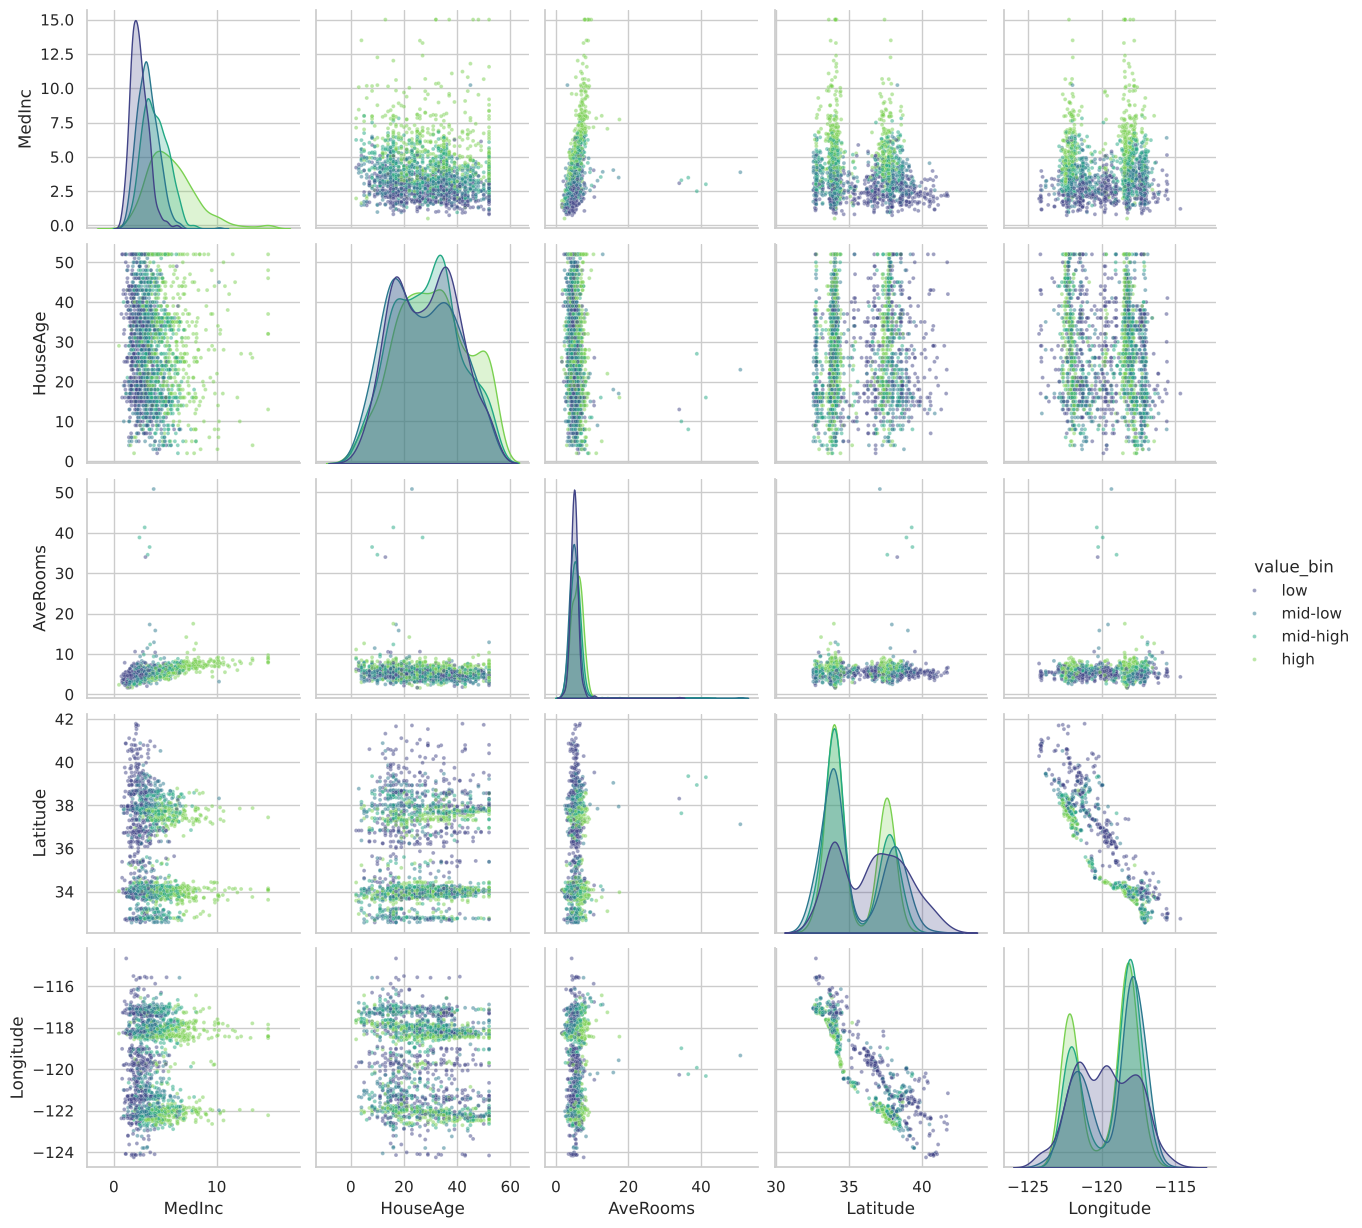

In [15]:
sample = df.sample(2000, random_state=0)
sample['value_bin'] = pd.qcut(sample['MedHouseVal'], 4, labels=['low', 'mid-low', 'mid-high', 'high'])
sns.pairplot(sample[['MedInc', 'HouseAge', 'AveRooms', 'Latitude', 'Longitude', 'value_bin']],
             hue='value_bin', palette='viridis', plot_kws={'s': 8, 'alpha': 0.5})
plt.show()

## Takeaways for modelling

* regression problem, 8 numeric features, no missing data
* features on very different scales and some extreme values, so scale for linear models / KNN / neural nets
* MedInc is the main signal, location adds a lot but non-linearly
* the target is capped at 5.0, so errors on expensive blocks will look worse than they really are
* errors are in units of $100k, so an MAE of 0.5 means about $50k off on average